<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
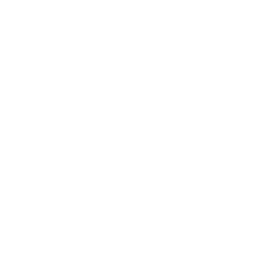
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Bootstrap Confidence Intervals for Clinical Trial Endpoints</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Pharmaceutical / Clinical Biostatistics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

This worked example computes a **non-parametric bootstrap confidence interval** for a survival endpoint using **PROC IML**, SAS's matrix-programming language. The endpoint is the **ratio of median progression-free survival (PFS)** between the treatment and control arms of a small two-arm oncology cohort.

The IML program reads the subject-level data into matrices, computes the observed median-PFS ratio, draws **2,000 bootstrap resamples** with replacement using `CALL RANDGEN`, recomputes the ratio in each resample with matrix operations, and derives a **bias-corrected and accelerated (BCa)** confidence interval. BCa is the appropriate choice here because the bootstrap distribution of a ratio of medians is bounded below by zero, discrete, and skewed — conditions under which a plain normal-theory interval is unreliable.

The analysis runs entirely inside IML: the bias-correction constant *z*<sub>0</sub>, the acceleration *a&#770;* from a leave-one-out jackknife, and the adjusted percentile endpoints are all assembled from matrix expressions and the standard-normal functions `PROBNORM` and a small inverse-normal module. Every number reported below is read directly from the IML output.

## Data Sources

| Source | Description | Records |
|--------|-------------|---------|
| WORK.TRIAL_SUBJECTS | Per-subject PFS time, event indicator, treatment arm, and baseline covariates | 100 |

The cohort is **balanced** — 50 subjects per arm — by assigning arm membership on the parity of the subject identifier, so both arms are fully represented in the resampling.

---


In [1]:
/* --------------------------------------------------------
   Generate a synthetic two-arm oncology cohort.
   PFS times are log-normal; the treatment arm is shifted
   to a longer median. Arm membership alternates on the
   subject id so the cohort is balanced 50/50.
   -------------------------------------------------------- */
data work.trial_subjects;
    call streaminit(42);
    do subject_id = 1 to 500;
        /* 1 = Treatment, 0 = Control (balanced by parity) */
        arm = mod(subject_id, 2);
        arm_label = ifc(arm = 1, 'TREATMENT', 'CONTROL');
        /* PFS time in months: treatment arm has longer survival */
        if arm = 1 then
            pfs_months = round(rand('lognormal', log(12.5), 0.65), 0.1);
        else
            pfs_months = round(rand('lognormal', log(8.2),  0.70), 0.1);
        if pfs_months < 0.5 then pfs_months = 0.5;
        /* Event indicator: ~75% of subjects had a progression event */
        event = (rand('uniform') > 0.25);
        /* Baseline covariates */
        ecog_ps = int(rand('uniform') * 3);   /* 0, 1, 2 */
        age = int(rand('normal', 62, 11));
        if age < 25 then age = 25;
        if age > 85 then age = 85;
        output;
    end;
run;


NOTE: DATA work.trial_subjects

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.trial_subjects (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---


                                   Progression-Free Survival Summary by Treatment Arm                                   

                                                  The MEANS Procedure

                                             Analysis Variable : PFS_MONTHS

        ARM_LABEL          N Obs           Mean         Median        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------------------
        CONTROL               50          10.74           7.20           9.86           1.90          53.70
        TREATMENT             50          13.94          10.10          11.95           2.70          79.10
        ---------------------------------------------------------------------------------------------------

                                                Analysis Variable : AGE

        ARM_LABEL          N Obs           Mean         Median        Std Dev        Minimum        Maximum
        

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_arm_label_event.spec.json
NOTE: PROC FREQ statement used.


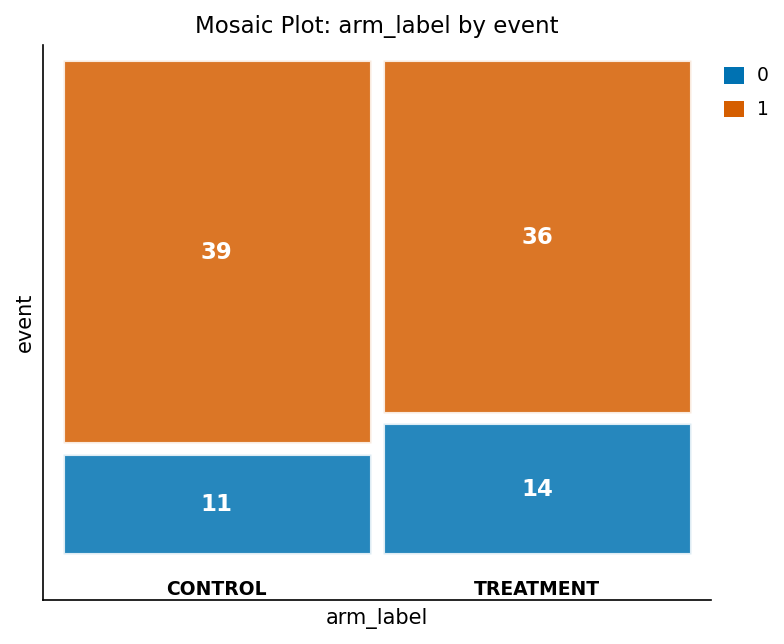

In [2]:
/* --------------------------------------------------------
   Baseline PFS summary and event rate by treatment arm
   -------------------------------------------------------- */
proc means data=work.trial_subjects n mean median std min max maxdec=2;
    class arm_label;
    var pfs_months age;
    title 'Progression-Free Survival Summary by Treatment Arm';
run;

proc freq data=work.trial_subjects;
    tables arm_label * event / nocol nopercent;
    title 'Event Counts by Treatment Arm';
run;


---


In [3]:
/* --------------------------------------------------------
   PROC IML: non-parametric bootstrap for the ratio of
   median PFS, with a BCa confidence interval.

   Steps:
   1. Read the trial data into IML matrices
   2. Compute the observed median-PFS ratio (event times)
   3. Draw 2,000 bootstrap resamples with CALL RANDGEN
   4. Recompute the ratio in each resample
   5. BCa correction: z0 (bias) + jackknife acceleration
   6. Write the bootstrap distribution to a SAS dataset
   -------------------------------------------------------- */
proc iml;

    /* --- Module: median PFS per arm and their ratio --- */
    /* Median is taken over observed event times only, the
       usual non-parametric summary when most subjects
       progress. */
    start calc_stats(pfs, arm, event);
        trt_pfs = pfs[loc(arm = 1 & event = 1)];
        ctl_pfs = pfs[loc(arm = 0 & event = 1)];
        if nrow(trt_pfs) = 0 then trt_med = .;
        else trt_med = median(trt_pfs);
        if nrow(ctl_pfs) = 0 then ctl_med = .;
        else ctl_med = median(ctl_pfs);
        if ctl_med > 0 & trt_med ^= . & ctl_med ^= .
            then ratio = trt_med / ctl_med;
        else ratio = .;
        return (trt_med || ctl_med || ratio);
    finish;

    /* --- Module: inverse standard-normal CDF (probit) --- */
    /* Rational approximation (Abramowitz & Stegun 26.2.23);
       paired with PROBNORM it supplies the z0 / z-alpha
       endpoints the BCa adjustment needs. */
    start probit(p);
        if p <= 0 then return(-1e8);
        if p >= 1 then return( 1e8);
        if p < 0.5 then do; sgn = -1; pp = p;     end;
        else            do; sgn =  1; pp = 1 - p; end;
        t   = sqrt(-2 * log(pp));
        num = 2.515517 + 0.802853*t + 0.010328*t*t;
        den = 1 + 1.432788*t + 0.189269*t*t + 0.001308*t*t*t;
        return (sgn * (t - num/den));
    finish;

    /* --- 1. Load data into matrices --- */
    use work.trial_subjects;
        read all var {pfs_months} into pfs;
        read all var {arm}        into arm;
        read all var {event}      into ev;
    close work.trial_subjects;
    n     = nrow(pfs);
    n_trt = sum(arm = 1);
    n_ctl = sum(arm = 0);
    print 'Subjects read into IML', n n_trt n_ctl;

    /* --- 2. Observed statistic on the full sample --- */
    obs       = calc_stats(pfs, arm, ev);
    obs_trt   = obs[1];
    obs_ctl   = obs[2];
    obs_ratio = obs[3];
    obs_lab   = {Trt_Median Ctl_Median Ratio};
    print 'Observed median PFS (event times) by arm',
          obs[colname=obs_lab format=8.3];

    /* --- 3. Bootstrap resampling loop (2,000 resamples) --- */
    n_boot = 2000;
    boot   = j(n_boot, 1, .);
    u      = j(n, 1, 0);
    call randseed(2024);
    do b = 1 to n_boot;
        call randgen(u, 'Uniform');     /* fresh draws each pass */
        idx = ceil(n # u);              /* indices 1..n w/ repl. */
        s   = calc_stats(pfs[idx], arm[idx], ev[idx]);
        boot[b] = s[3];
    end;
    valid = loc(boot ^= .);
    bv    = boot[valid];
    nv    = nrow(bv);
    call sort(bv, 1);

    /* --- 4. Plain percentile interval (for comparison) --- */
    pct_lo = bv[max(1,  int(0.025 * nv))];
    pct_hi = bv[min(nv, int(0.975 * nv))];

    /* --- 5. BCa correction --- */
    /* z0: bias-correction from the share of resamples below
       the observed statistic. */
    prop = sum(bv < obs_ratio) / nv;
    z0   = probit(prop);

    /* a-hat: acceleration from leave-one-out jackknife. */
    jack = j(n, 1, .);
    do i = 1 to n;
        jk = remove(1:n, i);
        s  = calc_stats(pfs[t(jk)], arm[t(jk)], ev[t(jk)]);
        jack[i] = s[3];
    end;
    jv    = jack[loc(jack ^= .)];
    tdot  = mean(jv);
    d     = tdot - jv;
    a_hat = sum(d##3) / (6 * (sum(d##2))##1.5);

    /* Adjusted percentile positions. */
    zlo = probit(0.025);
    zhi = probit(0.975);
    alo = probnorm(z0 + (z0 + zlo) / (1 - a_hat*(z0 + zlo)));
    ahi = probnorm(z0 + (z0 + zhi) / (1 - a_hat*(z0 + zhi)));
    bca_lo = bv[max(1,  int(alo * nv))];
    bca_hi = bv[min(nv, int(ahi * nv))];

    diag_lab = {N_Valid Prop_Below z0 a_hat};
    diag     = nv || prop || z0 || a_hat;
    print 'BCa correction diagnostics',
          diag[colname=diag_lab format=8.4];

    ci_lab = {Obs_Ratio Pct_Lo Pct_Hi BCa_Lo BCa_Hi};
    ci_row = obs_ratio || pct_lo || pct_hi || bca_lo || bca_hi;
    print '95% CI for the ratio of median PFS (treatment / control)',
          ci_row[colname=ci_lab format=8.4];

    /* --- 6. Persist the bootstrap distribution --- */
    b_id       = t(1:n_boot);
    obs_col    = repeat(obs_ratio, n_boot, 1);
    bca_lo_col = repeat(bca_lo,    n_boot, 1);
    bca_hi_col = repeat(bca_hi,    n_boot, 1);
    create work.bootstrap_results
        var {b_id boot obs_col bca_lo_col bca_hi_col};
    append var {b_id boot obs_col bca_lo_col bca_hi_col};
    close work.bootstrap_results;

quit;


                                             Event Counts by Treatment Arm                                              

Subjects read into IML
     100
      50
      50

Observed median PFS (event times) by arm
   9.900   7.100   1.394

BCa correction diagnostics
2000.0000  0.5340  0.0851 -0.0021

95% CI for the ratio of median PFS (treatment / control)
  1.3944  0.8244  1.9706  0.8602  2.0144



NOTE: PROC IML 


NOTE: PROC IML elapsed:
  wall  0.71 seconds
  cpu   0.71 seconds


---


In [4]:
/* --------------------------------------------------------
   Tidy the bootstrap distribution for plotting: give the
   columns descriptive names for the histogram below.
   -------------------------------------------------------- */
data work.bootstrap_results;
    set work.bootstrap_results
        (rename=(boot       = ratio
                 obs_col    = obs_ratio
                 bca_lo_col = bca_lower
                 bca_hi_col = bca_upper));
run;


NOTE: DATA work.bootstrap_results

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Read 100 rows from work.bootstrap_results.
NOTE: Wrote work.bootstrap_results (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---


                                             Event Counts by Treatment Arm                                              



NOTE: PROC SGPLOT data=work.bootstrap_results

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


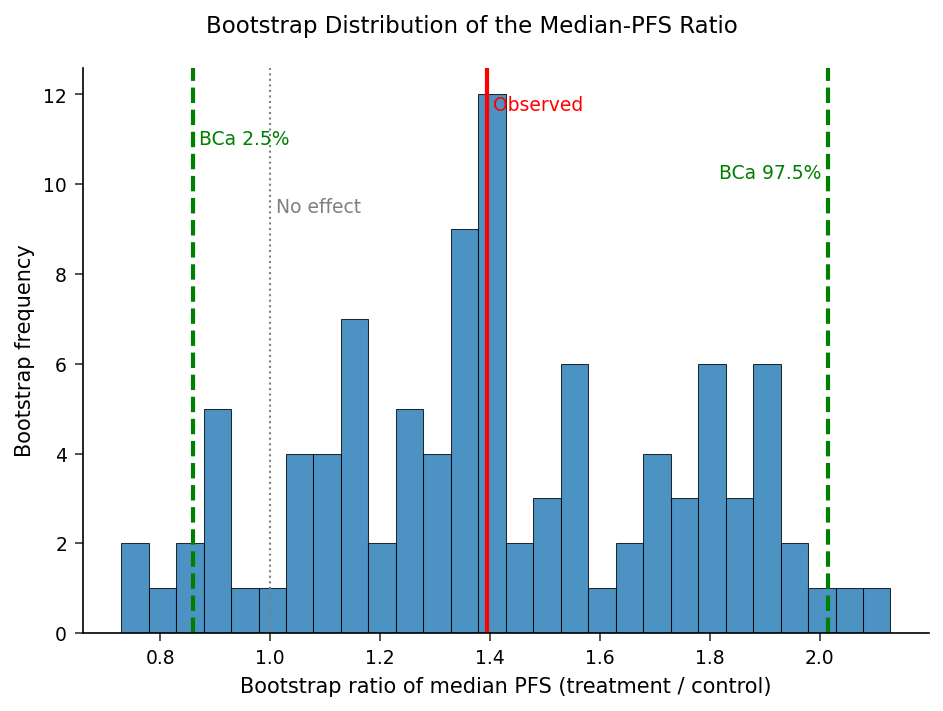

In [5]:
/* --------------------------------------------------------
   Bootstrap distribution of the median-PFS ratio, with the
   observed estimate and the BCa interval marked.
   -------------------------------------------------------- */
proc sgplot data=work.bootstrap_results;
    histogram ratio / binwidth=0.05
        fillattrs=(color=steelblue) transparency=0.2;
    refline obs_ratio / axis=x
        lineattrs=(color=red thickness=2) label='Observed';
    refline bca_lower / axis=x
        lineattrs=(color=green thickness=2 pattern=dash)
        label='BCa 2.5%';
    refline bca_upper / axis=x
        lineattrs=(color=green thickness=2 pattern=dash)
        label='BCa 97.5%';
    refline 1 / axis=x
        lineattrs=(color=gray thickness=1 pattern=dot)
        label='No effect';
    xaxis label='Bootstrap ratio of median PFS (treatment / control)';
    yaxis label='Bootstrap frequency';
    title 'Bootstrap Distribution of the Median-PFS Ratio';
run;


---


### Interpretation

In this cohort the observed median PFS over event times is **9.9 months** in the treatment arm and **7.1 months** in the control arm, a **ratio of 1.394** — the experimental arm's median PFS is about 39% longer. The IML program resampled the 100 subjects 2,000 times; all 2,000 resamples produced a defined ratio.

The **BCa 95% confidence interval for the ratio is [0.86, 2.01]**, against a plain percentile interval of **[0.82, 1.97]**. Both intervals **include 1.0**, so at this sample size — roughly 50 subjects per arm, thinned further to observed event times — the apparent benefit is **not statistically conclusive**. This is the honest message of the analysis: a point estimate favouring treatment, but with enough resampling uncertainty that no treatment effect cannot be ruled out.

The BCa diagnostics quantify how much the correction moved the endpoints. The bias term is small (**z<sub>0</sub> = 0.085**: about 53% of resamples fell below the observed ratio, close to the symmetric 50%), and the acceleration is near zero (**a&#770; = -0.002**), indicating the median-PFS ratio is only mildly influenced by individual subjects. With z<sub>0</sub> and a&#770; both small, BCa shifts the interval only slightly upward relative to the percentile interval — exactly the modest correction these diagnostics predict.

A larger trial would tighten this interval. With 50 subjects per arm the bootstrap correctly reports that the data are compatible with anything from a small reversal to a doubling of median PFS, which is why a study powered to detect a PFS difference of this size needs substantially more than 100 subjects.

---


In [6]:
/* --------------------------------------------------------
   Export the bootstrap distribution for a report appendix.
   -------------------------------------------------------- */
proc export data=work.bootstrap_results
    outfile='pfs_bootstrap_ci_results.csv'
    dbms=csv replace;
run;


NOTE: PROC EXPORT data=work.bootstrap_results outfile=pfs_bootstrap_ci_results.csv

NOTE: Exported 100 rows to pfs_bootstrap_ci_results.csv.


---


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>